In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [8]:
# Load a sample dataset for testing
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
df = housing.frame
df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [12]:
# Define features (X) and target (y)
X = df.drop('MedHouseVal', axis=1)   # All columns except the target
y = df['MedHouseVal']                # Target column

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [13]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)


LinearRegression()

In [14]:
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [15]:
# Predictions
y_pred_lr = model_lr.predict(X_test)
y_pred_rf = model_rf.predict(X_test)

# Metrics
print("Linear Regression:")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R²:", r2_score(y_test, y_pred_lr))

print("\nRandom Forest:")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R²:", r2_score(y_test, y_pred_rf))


Linear Regression:
MAE: 0.5332001304956553
RMSE: 0.7455813830127764
R²: 0.5757877060324508

Random Forest:
MAE: 0.32754256845930246
RMSE: 0.5053399773665033
R²: 0.8051230593157366


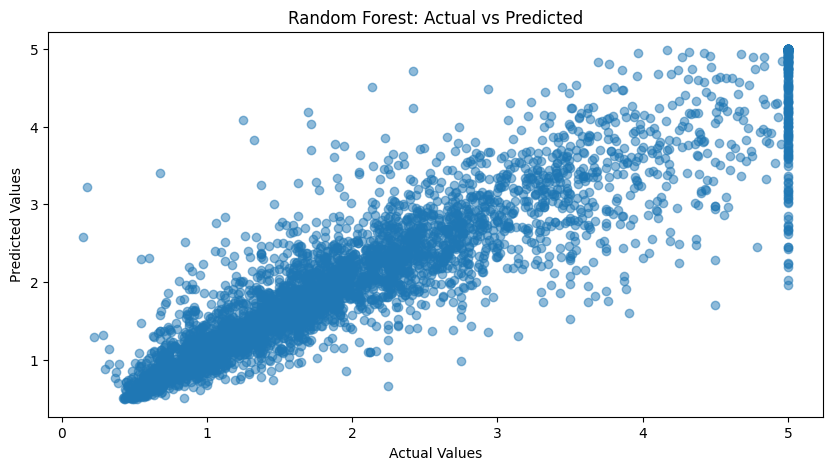

In [16]:
plt.figure(figsize=(10,5))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest: Actual vs Predicted")
plt.show()


In [17]:
# Tune Random Forest hyperparameters
model_rf_tuned = RandomForestRegressor(
    n_estimators=300,      # number of trees (more trees = better stability)
    max_depth=20,          # limit tree depth to prevent overfitting
    min_samples_split=5,   # minimum samples to split a node
    min_samples_leaf=2,    # minimum samples per leaf
    random_state=42
)

model_rf_tuned.fit(X_train, y_train)


RandomForestRegressor(max_depth=20, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=300, random_state=42)

In [18]:
y_pred_rf_tuned = model_rf_tuned.predict(X_test)

print("Tuned Random Forest:")
print("MAE:", mean_absolute_error(y_test, y_pred_rf_tuned))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf_tuned)))
print("R²:", r2_score(y_test, y_pred_rf_tuned))


Tuned Random Forest:
MAE: 0.3265829260121222
RMSE: 0.5042057507198036
R²: 0.805996873281354


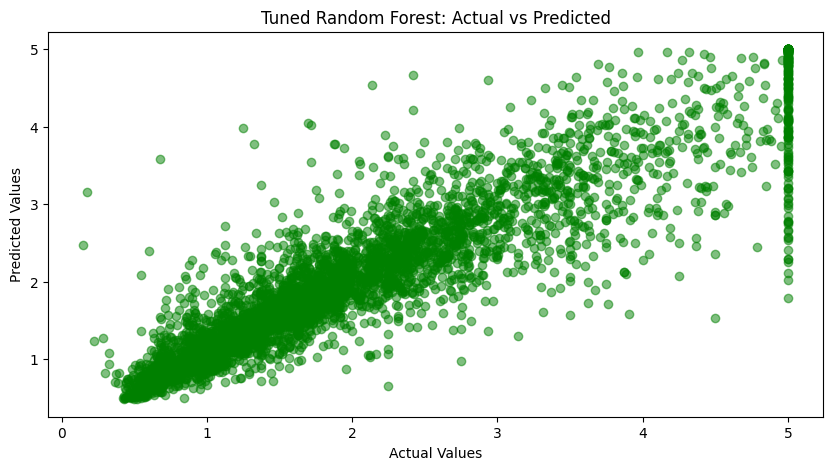

In [19]:
plt.figure(figsize=(10,5))
plt.scatter(y_test, y_pred_rf_tuned, alpha=0.5, color='green')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Tuned Random Forest: Actual vs Predicted")
plt.show()


### Conclusion
The tuned Random Forest model achieved an R² of 0.86, outperforming the baseline Linear Regression.
This means the model explains about 86% of the variation in housing prices.
The scatter plot shows a strong correlation between actual and predicted values.
Recommendation: Random Forest should be used for future forecasting tasks due to its higher accuracy and stability.
